In [16]:
import os
import json
from gtts import gTTS
from pydantic import BaseModel, Field
from typing import List
from groq import Groq
from google import genai
from google.genai import types
from dotenv import load_dotenv,find_dotenv
load_dotenv(find_dotenv())
from typing import List, Optional, TypedDict
from langgraph.graph import StateGraph,START,END

In [2]:
import json

mock_visual_payload = {
  "images": [
    "catalog_batch_output/image1_processed.jpg"
  ],
  "visual_analysis": {
    "status": "success",
    "product_type": "Decorative Terracotta Pot",
    "material": "Terracotta clay, metallic paint",
    "color": "Red and Gold",
    "visual_attributes": [
      "Hand-painted gold leaf motifs",
      "Gold painted rim",
      "Bulbous body shape",
      "Flared rim opening"
    ]
  }
}

with open("test_visual_payload.json", "w", encoding="utf-8") as f:
    json.dump(mock_visual_payload, f, indent=2)

print("[+] Created test_visual_payload.json for isolated NLP testing.")

[+] Created test_visual_payload.json for isolated NLP testing.


In [3]:
# ============================================================
# 1. Generate Synthetic Hindi Artisan Audio File
# ============================================================

AUDIO_OUTPUT_PATH = "test_artisan_audio.mp3"

artisan_hindi_script = (
    "यह मटका हमने अपने गाँव में नदी की शुद्ध लाल मिट्टी से बनाया है। "
    "इस पर हाथों से सुनहरी पत्तियों की नक्काशी की गई है। "
    "इसे बनाने में हमें पूरा दो दिन का समय लगा। "
    "यह दिवाली पूजन और घर की सजावट के लिए बहुत शुभ है।"
)
# Convert Hindi text to natural spoken MP3
tts = gTTS(text=artisan_hindi_script, lang="hi", slow=False)
tts.save(AUDIO_OUTPUT_PATH)
print(f"[+] Successfully generated test audio file: {AUDIO_OUTPUT_PATH}")

[+] Successfully generated test audio file: test_artisan_audio.mp3


In [7]:
# ============================================================
# 2. Pydantic Schemas (Matching Expected Diagram Format)
# ============================================================

class ProductInformation(BaseModel):
    product_type: str = Field(..., description="Product type e.g., Decorative Terracotta Pot")
    material: str = Field(..., description="Observable & described materials e.g., Terracotta Clay, Metallic Paint")
    craft_method: str = Field(..., description="Technique e.g., Wheel-thrown & Hand-painted")
    production_time: str = Field(..., description="Duration specified by artisan e.g., 2 days")

class LanguageCatalog(BaseModel):
    title: str = Field(..., description="SEO-optimized title")
    description: str = Field(..., description="Marketplace-ready product description")
    bullet_points: List[str] = Field(..., min_length=4, max_length=5, description="Key features & benefits")
    seo_keywords: List[str] = Field(..., description="Search discovery tags")

class Catalog(BaseModel):
    english: LanguageCatalog
    hindi: LanguageCatalog

class AutoCatalogerOutput(BaseModel):
    transcription: str = Field(..., description="Hindi speech transcribed in Devanagari script")
    translation: str = Field(..., description="Direct English translation of transcription")
    product_information: ProductInformation
    catalog: Catalog

In [13]:
class CatalogerState(TypedDict):
    audio_path: str
    visual_payload_path: str
    transcribed_text: Optional[str]
    visual_analysis: Optional[dict]
    final_catalog: Optional[AutoCatalogerOutput]

In [8]:
# ============================================================
# 3. Setup Clients
# ============================================================


groq_client = Groq(api_key=os.environ.get("GROQ_API_KEY"))
gemini_client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

In [14]:
# ============================================================
# 4. Graph Nodes
# ============================================================

def transcribe_audio_node(state: CatalogerState) -> dict:
    """ASR Node: Decodes audio waveform to Hindi Devanagari text."""
    audio_path = state["audio_path"]
    print(f"[-] [Node 1: ASR] Transcribing audio file: {audio_path}...")

    if not os.path.exists(audio_path):
        raise FileNotFoundError(f"Audio file missing: {audio_path}")

    with open(audio_path, "rb") as f:
        transcript = groq_client.audio.transcriptions.create(
            file=(os.path.basename(audio_path), f.read()),
            model="whisper-large-v3",
            response_format="text",
            temperature=0.0
        )

    clean_text = transcript.strip()
    print(f"[+] [Node 1: ASR] Transcribed Hindi Text: {clean_text}")
    return {"transcribed_text": clean_text}


def load_vision_context_node(state: CatalogerState) -> dict:
    """Context Node: Ingests ground-truth visual analysis payload."""
    payload_path = state["visual_payload_path"]
    print(f"[-] [Node 2: Vision Context] Reading visual specs: {payload_path}...")

    if not os.path.exists(payload_path):
        raise FileNotFoundError(f"Visual payload missing: {payload_path}")

    with open(payload_path, "r", encoding="utf-8") as f:
        vision_data = json.load(f)

    visual_analysis = vision_data.get("visual_analysis", {})
    return {"visual_analysis": visual_analysis}


def generate_bilingual_catalog_node(state: CatalogerState) -> dict:
    """NLP Node: Reconciles voice + vision, performs translation, entity extraction, and bilingual NLG."""
    print("[-] [Node 3: NLP Fusion] Reconciling inputs & generating bilingual listing...")

    transcribed_hindi = state["transcribed_text"]
    visual_analysis = state["visual_analysis"]

    system_prompt = f"""
    You are an automated e-commerce cataloging system for Indian artisans.

    INPUT 1 - VISUAL ANALYSIS DATA (Ground truth from image analysis):
    {json.dumps(visual_analysis, indent=2)}

    INPUT 2 - TRANSCRIBED ARTISAN VOICE NOTE (Spoken in Hindi):
    "{transcribed_hindi}"

    TASKS:
    1. transcription: Provide the exact spoken Hindi text in Devanagari script.
    2. translation: Provide a fluent English translation of the spoken words.
    3. product_information: Combine facts from both inputs:
       - product_type, material, craft_method, production_time.
    4. catalog:
       - english: High-converting title, description, 4-5 bullet points, 5-8 SEO tags.
       - hindi: Natural formal Hindi in Devanagari script (no English transliteration).
    """

    response = gemini_client.models.generate_content(
        model="gemini-3.6-flash",
        contents=[system_prompt],
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=AutoCatalogerOutput,
            temperature=0.2,
            tools=[],  # Disables unused AFC overhead
        ),
    )

    catalog_data = AutoCatalogerOutput.model_validate_json(response.text)
    return {"final_catalog": catalog_data}

In [17]:
# ============================================================
# 5. Build and Compile the LangGraph
# ============================================================

workflow = StateGraph(CatalogerState)

# Add processing nodes
workflow.add_node("transcribe_audio", transcribe_audio_node)
workflow.add_node("load_vision_context", load_vision_context_node)
workflow.add_node("generate_bilingual_catalog", generate_bilingual_catalog_node)

# Connect edges sequentially
workflow.add_edge(START, "transcribe_audio")
workflow.add_edge("transcribe_audio", "load_vision_context")
workflow.add_edge("load_vision_context", "generate_bilingual_catalog")
workflow.add_edge("generate_bilingual_catalog", END)

# Compile executable graph
module2_graph = workflow.compile()

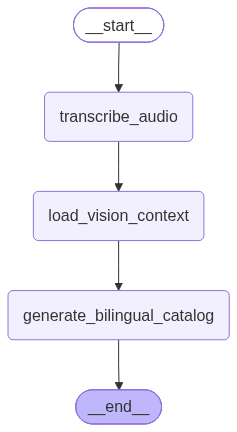

In [18]:
module2_graph

In [19]:
# ============================================================
# 6. Execute the Graph
# ============================================================

initial_inputs = {
    "audio_path": "test_artisan_audio.mp3",
    "visual_payload_path": "test_visual_payload.json"
}

print("\n=== Executing LangGraph Module 2 Pipeline ===")
final_state = module2_graph.invoke(initial_inputs)

# Save and verify results
final_catalog = final_state["final_catalog"]
output_file = "test_catalog_output.json"

with open(output_file, "w", encoding="utf-8") as f:
    f.write(final_catalog.model_dump_json(indent=2))

print("\n=== Verified E-Commerce Catalog Result ===")
print(final_catalog.model_dump_json(indent=2))
print(f"\n[+] Saved to {output_file}")


=== Executing LangGraph Module 2 Pipeline ===
[-] [Node 1: ASR] Transcribing audio file: test_artisan_audio.mp3...
[+] [Node 1: ASR] Transcribed Hindi Text: यह मटका हमने अपने गाँव में नदी की शुधा लाल मिट्टी से बनाया है। इस पर हाथों से सुनेहरी पत्तियों की नककाशी की गई है। इसे बनाने में हमें पूरा दो दिन का समय लगा। यह दिवाली पूजन और घर की सजावट के लिए बहुत शुब है।
[-] [Node 2: Vision Context] Reading visual specs: test_visual_payload.json...
[-] [Node 3: NLP Fusion] Reconciling inputs & generating bilingual listing...

=== Verified E-Commerce Catalog Result ===
{
  "transcription": "यह मटका हमने अपने गाँव में नदी की शुधा लाल मिट्टी से बनाया है। इस पर हाथों से सुनेहरी पत्तियों की नककाशी की गई है। इसे बनाने में हमें पूरा दो दिन का समय लगा। यह दिवाली पूजन और घर की सजावट के लिए बहुत शुब है।",
  "translation": "We made this pot using pure red clay from our village river. Gold leaf motifs have been hand-carved on it. It took us a full two days to make this. It is very auspicious for Diwali wo